# Microglia near T-cell+ vs T-cell- plaques

Marks each alpha-shape plaque by whether a CD8 T cell sits within 50 um of its
circumference, groups the nearby microglia by that status, and tests for
differential expression between the groups.

No image work is needed: `nearest_plaque_id` and `plaque_edge_distance_um` are
already per-cell in the h5ad, and `uns['plaque_table']` holds the 583 plaques.

**Headline: no microglial gene survives the controls.** Read the last section.

## 0. Load the object, with CD8/CD4 T cells labelled

Everything below needs `manual_celltype` to carry `Cd8 T-cells` and `Cd4 T-cells`,
which `12_lymphocyte_pca_subclustering` produces. Rather than re-running that
notebook, the labels are restored from the two subsets it saved and cached as a
combined object, so this notebook runs standalone from the second time onward.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

sc.settings.verbosity = 1

RESULTS_DIR = Path(
    "/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/"
    "AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/"
    "RESULTS/20240627__192310__KAECH_AD_GBM_240627"
)
OUTPUT_DIR = RESULTS_DIR / "10_Lymphocyte_Subclustering"

# Written by 08_plaque_detected_alpha_pipeline: plaque distances, no T-cell labels.
BASE_H5AD = (RESULTS_DIR / "08_Plaque_Proximity_Analysis"
             / "adata_combined_with_alphashape_plaque_edge_15_20_30_40um.h5ad")
# Written by 12_lymphocyte_pca_subclustering.
LYMPHOCYTE_H5AD = OUTPUT_DIR / "lymphocytes_pca_leiden_res0.1.h5ad"
TCELL_H5AD = OUTPUT_DIR / "tcells_pca_leiden_res0.2.h5ad"
# Cached combined object with the CD8/CD4 labels already applied.
LABELLED_H5AD = OUTPUT_DIR / "adata_combined_with_tcell_labels.h5ad"

CELLTYPE_KEY = "manual_celltype"
LYMPHOCYTE_LABEL = "Lymphocytes"
TCELL_CLUSTER = "0"          # the T-cell cluster of the res-0.1 lymphocyte run
TCELL_LABEL = "Cd8 T-cells"
CD4_LABEL = "Cd4 T-cells"

for path in [BASE_H5AD, LYMPHOCYTE_H5AD, TCELL_H5AD, LABELLED_H5AD]:
    print(f"{'found  ' if path.exists() else 'missing'}  {path.name}")

found    adata_combined_with_alphashape_plaque_edge_15_20_30_40um.h5ad
found    lymphocytes_pca_leiden_res0.1.h5ad
found    tcells_pca_leiden_res0.2.h5ad
found    adata_combined_with_tcell_labels.h5ad


Both subsets were written by boolean subsetting in parent order, so the parent
positions of the `Lymphocytes` recover the subset row order exactly. The mapping is
positional rather than by barcode, because obs_names repeat between the infected and
mock sections.

In [2]:
def restore_tcell_labels(adata, lymphocytes, tcells):
    """Put Cd8/Cd4 T-cell labels back onto manual_celltype.

    Both subsets were produced by boolean subsetting in parent order, so the
    parent positions of the Lymphocytes recover the subset row order exactly.
    Positional, not by barcode: obs_names repeat between the two sections.
    """
    positions = np.flatnonzero((adata.obs[CELLTYPE_KEY] == LYMPHOCYTE_LABEL).to_numpy())
    assert len(positions) == lymphocytes.n_obs, "lymphocyte count does not match"
    assert (adata.obs_names[positions] == lymphocytes.obs_names).all(), "row order mismatch"

    is_tcell = (lymphocytes.obs["lymphocyte_leiden"] == TCELL_CLUSTER).to_numpy()
    tcell_positions = positions[is_tcell]
    assert len(tcell_positions) == tcells.n_obs, "T-cell count does not match"

    # Prefer the saved call; otherwise rebuild it from the markers, so this
    # works whether or not the labelling cell was run before saving.
    if "tcell_subtype" in tcells.obs:
        subtype = tcells.obs["tcell_subtype"].astype(str).to_numpy()
    else:
        detected = (tcells[:, ["Cd8a", "Cd8b1", "Cd4"]].X.toarray() > 0)
        called = pd.DataFrame({
            "cd8": detected[:, :2].any(axis=1), "cd4": detected[:, 2],
        }).groupby(tcells.obs["tcell_leiden"].to_numpy()).mean()
        mapping = np.where(called["cd4"] > called["cd8"], CD4_LABEL, TCELL_LABEL)
        subtype = pd.Series(tcells.obs["tcell_leiden"].astype(str).to_numpy()).map(
            dict(zip(called.index.astype(str), mapping))
        ).to_numpy()
        print("rebuilt the CD8/CD4 call from markers:",
              dict(zip(called.index.astype(str), mapping)))

    labels = adata.obs[CELLTYPE_KEY].astype(str).to_numpy()
    labels[tcell_positions] = subtype
    adata.obs[CELLTYPE_KEY] = pd.Categorical(labels)
    return adata


if LABELLED_H5AD.exists():
    adata = ad.read_h5ad(LABELLED_H5AD)
    print("loaded cached", LABELLED_H5AD.name)
else:
    adata = ad.read_h5ad(BASE_H5AD)
    adata = restore_tcell_labels(
        adata, ad.read_h5ad(LYMPHOCYTE_H5AD), ad.read_h5ad(TCELL_H5AD)
    )
    adata.write_h5ad(LABELLED_H5AD, compression="gzip")
    print("built and cached", LABELLED_H5AD.name)

assert {TCELL_LABEL, CD4_LABEL} <= set(adata.obs[CELLTYPE_KEY].cat.categories), (
    "T-cell labels missing - run 12_lymphocyte_pca_subclustering first"
)
print()
print(adata.obs[CELLTYPE_KEY].value_counts().reindex(
    [TCELL_LABEL, CD4_LABEL, LYMPHOCYTE_LABEL, "Microglia"]).to_string())
print()
print("plaques:", len(adata.uns["plaque_table"]),
      "| scored cells:", int(adata.obs["plaque_proximity_valid"].sum()))

loaded cached adata_combined_with_tcell_labels.h5ad

manual_celltype
Cd8 T-cells     223
Cd4 T-cells      17
Lymphocytes     189
Microglia      8738

plaques: 583 | scored cells: 55214


## 1. Mark plaques T-cell+ / T-cell-

Same definition notebook 09 used - at least one T cell within 50 um of the plaque
edge - but using the refined `Cd8 T-cells` label rather than all `Lymphocytes`.

In [3]:
# ---- Mark each plaque T-cell positive / negative --------------------------
T_CELL_LABELS = ["Cd8 T-cells"]          # add "Cd4 T-cells" to count both
TCELL_NEAR_UM = 50                        # same definition notebook 09 used
POSITIVE_MINIMUM = 1                      # >= this many T cells makes a plaque +

obs = adata.obs
scored = obs["plaque_proximity_valid"].astype(bool).to_numpy()

is_tcell = obs["manual_celltype"].isin(T_CELL_LABELS).to_numpy()
tcell_near = scored & is_tcell & (obs["plaque_edge_distance_um"] < TCELL_NEAR_UM).to_numpy()
tcell_counts = obs.loc[tcell_near, "nearest_plaque_id"].astype(int).value_counts()

plaque_status = adata.uns["plaque_table"].copy()
plaque_status["plaque_id"] = plaque_status["plaque_id"].astype(int)
plaque_status["n_tcells_near"] = (
    plaque_status["plaque_id"].map(tcell_counts).fillna(0).astype(int)
)
plaque_status["tcell_status"] = np.where(
    plaque_status["n_tcells_near"] >= POSITIVE_MINIMUM, "T-cell positive", "T-cell negative"
)

print(f"T cells ({'/'.join(T_CELL_LABELS)}) within {TCELL_NEAR_UM} um of a plaque: "
      f"{int(tcell_near.sum())}")
print(plaque_status["tcell_status"].value_counts().to_string())

# Are the two plaque groups otherwise comparable? A size difference would
# confound any microglial DEG that follows.
display(
    plaque_status.groupby("tcell_status")[["area_um2", "equivalent_diameter_um", "perimeter_um"]]
    .median().round(1)
)

status_map = plaque_status.set_index("plaque_id")["tcell_status"]
count_map = plaque_status.set_index("plaque_id")["n_tcells_near"]
nearest = obs["nearest_plaque_id"]
adata.obs["plaque_tcell_status"] = nearest.map(status_map).astype("category")
adata.obs["plaque_tcell_count"] = nearest.map(count_map).astype("Int64")

T cells (Cd8 T-cells) within 50 um of a plaque: 51
tcell_status
T-cell negative    539
T-cell positive     44


,area_um2,equivalent_diameter_um,perimeter_um
tcell_status,,,
T-cell negative,95.9,11.1,33.9
T-cell positive,175.0,14.9,46.8


## 2. Group the microglia

Each microglion is assigned to its nearest plaque, and inherits that plaque's status.

In [4]:
# ---- Microglia near T+ vs T- plaques --------------------------------------
MICROGLIA_LABEL = "Microglia"
MICROGLIA_NEAR_UM = 50

near_plaque = scored & (adata.obs["plaque_edge_distance_um"] < MICROGLIA_NEAR_UM).to_numpy()
is_microglia = (adata.obs["manual_celltype"] == MICROGLIA_LABEL).to_numpy()
microglia_mask = near_plaque & is_microglia

adata.obs["microglia_plaque_group"] = pd.Categorical(
    np.where(microglia_mask, adata.obs["plaque_tcell_status"].astype(str), None),
    categories=["T-cell negative", "T-cell positive"],
)

microglia = adata[microglia_mask].copy()
print(f"Microglia within {MICROGLIA_NEAR_UM} um of a plaque: {microglia.n_obs}")
print(microglia.obs["plaque_tcell_status"].value_counts().to_string())

# Confounder check. If these differ, the DEG reflects them and not T cells.
display(
    microglia.obs.groupby("plaque_tcell_status", observed=True)[
        ["plaque_edge_distance_um", "transcript_counts", "n_genes_by_counts", "cell_area"]
    ].median().round(1)
)
print("plaques contributing microglia:",
      microglia.obs.groupby("plaque_tcell_status", observed=True)["nearest_plaque_id"].nunique().to_dict())

Microglia within 50 um of a plaque: 1936
plaque_tcell_status
T-cell negative    1698
T-cell positive     238


,plaque_edge_distance_um,transcript_counts,n_genes_by_counts,cell_area
plaque_tcell_status,,,,
T-cell negative,10.3,236.0,89.0,68.7
T-cell positive,7.7,214.5,81.0,63.0


plaques contributing microglia: {'T-cell negative': 432, 'T-cell positive': 40}


## 3. DEG, with two controls

The naive cell-level test is run first, then two controls that it needs:

- **Area matching.** T+ plaques are larger, and a larger plaque is a different niche
  regardless of T cells. Each T+ plaque is matched to the closest T- plaque by area.
- **Per-plaque pseudobulk.** Microglia around the same plaque are not independent,
  so the plaque, not the cell, is the unit of replication.

In [5]:
# ---- DEG: microglia near T+ vs T- plaques ---------------------------------
GROUP_KEY = "plaque_tcell_status"
REFERENCE = "T-cell negative"

def wilcoxon_deg(data, group_key, reference):
    sc.tl.rank_genes_groups(data, groupby=group_key, groups=["T-cell positive"],
                            reference=reference, method="wilcoxon", tie_correct=True)
    return (sc.get.rank_genes_groups_df(data, group="T-cell positive")
            .set_index("names")[["logfoldchanges", "pvals", "pvals_adj"]])

microglia.obs[GROUP_KEY] = microglia.obs[GROUP_KEY].cat.remove_unused_categories()
deg_all = wilcoxon_deg(microglia, GROUP_KEY, REFERENCE)

# T+ plaques are larger, and plaque size alone changes the local niche. Match
# each T+ plaque to the closest T- plaque by area, without replacement, so the
# comparison is not just large plaques vs small ones.
area = plaque_status.set_index("plaque_id")["area_um2"]
positive_ids = plaque_status.loc[plaque_status.tcell_status == "T-cell positive", "plaque_id"]
candidates = list(plaque_status.loc[plaque_status.tcell_status == REFERENCE, "plaque_id"])

matched = []
for pid in positive_ids:
    if not candidates:
        break
    best = min(candidates, key=lambda c: abs(area[c] - area[pid]))
    matched.append(best)
    candidates.remove(best)

keep = microglia.obs["nearest_plaque_id"].isin(
    list(positive_ids) + matched
).to_numpy()
microglia_matched = microglia[keep].copy()
microglia_matched.obs[GROUP_KEY] = microglia_matched.obs[GROUP_KEY].cat.remove_unused_categories()

print("area-matched set:", microglia_matched.obs[GROUP_KEY].value_counts().to_dict())
display(
    plaque_status.set_index("plaque_id").loc[list(positive_ids) + matched]
    .groupby("tcell_status")["area_um2"].median().round(1)
)
deg_matched = wilcoxon_deg(microglia_matched, GROUP_KEY, REFERENCE)

# Cells near the same plaque are not independent, so also test across plaques:
# one pseudobulk profile per plaque, Mann-Whitney between the two groups.
from scipy.stats import mannwhitneyu
frame = pd.DataFrame(microglia.X.toarray(), columns=microglia.var_names,
                     index=microglia.obs["nearest_plaque_id"].astype(int).to_numpy())
pseudobulk = frame.groupby(level=0).mean()
plaque_group = plaque_status.set_index("plaque_id")["tcell_status"].reindex(pseudobulk.index)
pos, neg = pseudobulk[plaque_group == "T-cell positive"], pseudobulk[plaque_group == REFERENCE]
print(f"pseudobulk plaques: {len(pos)} T+ vs {len(neg)} T-")

pb = pd.DataFrame({
    "pseudobulk_lfc": np.log2((pos.mean() + 1e-9) / (neg.mean() + 1e-9)),
    "pseudobulk_p": [mannwhitneyu(pos[g], neg[g]).pvalue for g in pseudobulk.columns],
}, index=pseudobulk.columns)
pb["pseudobulk_padj"] = np.minimum(pb["pseudobulk_p"] * len(pb), 1)

results = (deg_all.add_prefix("all_")
           .join(deg_matched.add_prefix("matched_"))
           .join(pb)
           .sort_values("all_pvals_adj"))
results["significant_everywhere"] = (
    (results["all_pvals_adj"] < 0.05)
    & (results["matched_pvals_adj"] < 0.05)
    & (results["pseudobulk_padj"] < 0.05)
    & (np.sign(results["all_logfoldchanges"]) == np.sign(results["matched_logfoldchanges"]))
)

print()
print("significant (padj<0.05): all cells", int((results.all_pvals_adj < 0.05).sum()),
      "| area-matched", int((results.matched_pvals_adj < 0.05).sum()),
      "| per-plaque", int((results.pseudobulk_padj < 0.05).sum()),
      "| all three", int(results.significant_everywhere.sum()))
display(results.head(20).round(4))

area-matched set: {'T-cell positive': 238, 'T-cell negative': 210}


/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


tcell_status
T-cell negative    175.9
T-cell positive    175.0
Name: area_um2, dtype: float64

/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


pseudobulk plaques: 40 T+ vs 432 T-

significant (padj<0.05): all cells 23 | area-matched 2 | per-plaque 4 | all three 0


,all_logfoldchanges,all_pvals,all_pvals_adj,matched_logfoldchanges,matched_pvals,matched_pvals_adj,pseudobulk_lfc,pseudobulk_p,pseudobulk_padj,significant_everywhere
names,,,,,,,,,,
Ccl5,2.1713,0.0000,0.0001,3.203400,0.0018,0.1098,2.7687,0.0000,0.0000,False
Cd8a,2.5785,0.0000,0.0001,24.820299,0.0016,0.1098,2.6377,0.0000,0.0005,False
Cd3e,2.9710,0.0000,0.0002,24.298201,0.0074,0.2223,3.4012,0.0000,0.0048,False
Cox5a,-0.5976,0.0000,0.0015,-0.489400,0.0187,0.3909,-0.0271,0.2859,1.0000,False
Thy1,-0.7380,0.0000,0.0015,-0.734500,0.0025,0.1348,0.0000,0.4494,1.0000,False
Dclk1,-0.7951,0.0000,0.0015,-0.997500,0.0000,0.0092,-0.1407,0.3727,1.0000,False
Pgam1,-0.4914,0.0000,0.0016,-0.500300,0.0017,0.1098,-0.0074,0.4429,1.0000,False
Cx3cl1,-0.7610,0.0000,0.0016,-0.741300,0.0032,0.1383,-0.0002,0.5911,1.0000,False
Tubb3,-0.6306,0.0000,0.0016,-0.551300,0.0067,0.2166,-0.0365,0.2247,1.0000,False


## 4. Are the hits just T-cell transcripts?

A microglion beside a T cell picks up T-cell transcripts through ambient RNA and
segmentation spillover. That is circular - the grouping variable produces the
readout - so genes that are simply T-cell genes are flagged.

In [6]:
# Microglia sitting beside a T cell pick up T-cell transcripts through ambient
# RNA and segmentation spillover. That is circular: the grouping variable
# causes the readout. Flag genes that are simply T-cell genes.
tcell_cells = adata[(adata.obs["manual_celltype"] == "Cd8 T-cells").to_numpy()]
mean_tcell = np.asarray(tcell_cells.X.mean(axis=0)).ravel()
mean_microglia = np.asarray(microglia.X.mean(axis=0)).ravel()
spillover = pd.Series(mean_tcell > 2 * mean_microglia, index=adata.var_names)

results["likely_tcell_spillover"] = spillover.reindex(results.index).fillna(False)

significant = results.loc[results.all_pvals_adj < 0.05]
print("significant in the naive (all-cell) test:", len(significant))
print("  of which are T-cell genes (spillover):",
      int(significant.likely_tcell_spillover.sum()))
print()
display(significant[["all_logfoldchanges", "all_pvals_adj", "matched_pvals_adj",
                     "pseudobulk_padj", "likely_tcell_spillover"]].round(4))

surviving = results.loc[
    (results.all_pvals_adj < 0.05) & (~results.likely_tcell_spillover)
    & (results.matched_pvals_adj < 0.05)
]
print()
print("microglial genes surviving the area-matched control:", len(surviving))

significant in the naive (all-cell) test: 23
  of which are T-cell genes (spillover): 8



,all_logfoldchanges,all_pvals_adj,matched_pvals_adj,pseudobulk_padj,likely_tcell_spillover
names,,,,,
Ccl5,2.1713,0.0001,0.1098,0.0000,True
Cd8a,2.5785,0.0001,0.1098,0.0005,True
Cd3e,2.9710,0.0002,0.2223,0.0048,True
Cox5a,-0.5976,0.0015,0.3909,1.0000,False
Thy1,-0.7380,0.0015,0.1348,1.0000,True
Dclk1,-0.7951,0.0015,0.0092,1.0000,False
Pgam1,-0.4914,0.0016,0.1098,1.0000,False
Cx3cl1,-0.7610,0.0016,0.1383,1.0000,False
Tubb3,-0.6306,0.0016,0.2166,1.0000,False



microglial genes surviving the area-matched control: 2


## 5. Save

In [7]:
# ---- Save -----------------------------------------------------------------
DEG_DIR = OUTPUT_DIR.parent / "11_Microglia_Tcell_Plaques"
DEG_DIR.mkdir(parents=True, exist_ok=True)

adata.uns["plaque_tcell_classification"] = {
    "tcell_labels": T_CELL_LABELS,
    "tcell_within_um": float(TCELL_NEAR_UM),
    "positive_minimum_tcells": int(POSITIVE_MINIMUM),
    "microglia_within_um": float(MICROGLIA_NEAR_UM),
    "n_positive_plaques": int((plaque_status.tcell_status == "T-cell positive").sum()),
    "n_negative_plaques": int((plaque_status.tcell_status == "T-cell negative").sum()),
    "median_area_positive_um2": float(
        plaque_status.loc[plaque_status.tcell_status == "T-cell positive", "area_um2"].median()),
    "median_area_negative_um2": float(
        plaque_status.loc[plaque_status.tcell_status == "T-cell negative", "area_um2"].median()),
    "note": ("T+ plaques are larger, so the area-matched comparison is the "
             "primary result; T-cell genes in microglia are spillover."),
    "created": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
}

plaque_status.to_csv(DEG_DIR / "plaque_tcell_status.csv", index=False)
with pd.ExcelWriter(DEG_DIR / "microglia_tcell_plaque_DEG.xlsx", engine="openpyxl") as writer:
    results.round(5).to_excel(writer, sheet_name="DEG_all_tests")
    results.loc[results.all_pvals_adj < 0.05].round(5).to_excel(writer, sheet_name="naive_significant")
    plaque_status.to_excel(writer, sheet_name="plaque_status", index=False)
    microglia.obs.groupby("plaque_tcell_status", observed=True)[
        ["plaque_edge_distance_um", "transcript_counts", "n_genes_by_counts", "cell_area"]
    ].median().round(2).to_excel(writer, sheet_name="group_qc")

PARENT_H5AD = DEG_DIR / "adata_combined_with_plaque_tcell_status.h5ad"
adata.write_h5ad(PARENT_H5AD, compression="gzip")
print("Wrote", DEG_DIR)
print("obs columns added:", ["plaque_tcell_status", "plaque_tcell_count", "microglia_plaque_group"])

Wrote /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/11_Microglia_Tcell_Plaques
obs columns added: ['plaque_tcell_status', 'plaque_tcell_count', 'microglia_plaque_group']


## 6. Same comparison, every cell type

The microglial result is only interpretable next to the other cell types. Each is
run through the same three tests, with the plaque area matching built once since it
is a plaque-level property.

In [8]:
# ---- Same comparison, every cell type -------------------------------------
from scipy.stats import mannwhitneyu

MINIMUM_GROUP_CELLS = 30     # smaller group must have at least this many cells
POSITIVE = "T-cell positive"
NEGATIVE = "T-cell negative"

near_plaque = scored & (adata.obs["plaque_edge_distance_um"] < MICROGLIA_NEAR_UM).to_numpy()

# Plaque area matching is plaque-level, so build the matched set once.
area = plaque_status.set_index("plaque_id")["area_um2"]
positive_ids = list(plaque_status.loc[plaque_status.tcell_status == POSITIVE, "plaque_id"])
candidates = list(plaque_status.loc[plaque_status.tcell_status == NEGATIVE, "plaque_id"])
matched_ids = []
for pid in positive_ids:
    if not candidates:
        break
    best = min(candidates, key=lambda c: abs(area[c] - area[pid]))
    matched_ids.append(best)
    candidates.remove(best)
MATCHED_PLAQUES = positive_ids + matched_ids

tcell_mean = np.asarray(
    adata[(adata.obs["manual_celltype"] == "Cd8 T-cells").to_numpy()].X.mean(axis=0)
).ravel()


def deg_for_celltype(label):
    """Naive, area-matched and per-plaque tests for one cell type."""
    cells = adata[near_plaque & (adata.obs["manual_celltype"] == label).to_numpy()].copy()
    cells.obs["grp"] = cells.obs["plaque_tcell_status"].cat.remove_unused_categories()
    if cells.obs["grp"].nunique() < 2:
        return None
    if cells.obs["grp"].value_counts().min() < MINIMUM_GROUP_CELLS:
        return None

    def wilcox(data):
        sc.tl.rank_genes_groups(data, groupby="grp", groups=[POSITIVE], reference=NEGATIVE,
                                method="wilcoxon", tie_correct=True)
        return (sc.get.rank_genes_groups_df(data, group=POSITIVE)
                .set_index("names")[["logfoldchanges", "pvals_adj"]])

    naive = wilcox(cells).add_prefix("naive_")

    keep = cells.obs["nearest_plaque_id"].isin(MATCHED_PLAQUES).to_numpy()
    matched_cells = cells[keep].copy()
    matched_cells.obs["grp"] = matched_cells.obs["grp"].cat.remove_unused_categories()
    if matched_cells.obs["grp"].nunique() == 2 and matched_cells.obs["grp"].value_counts().min() >= 10:
        matched = wilcox(matched_cells).add_prefix("matched_")
    else:
        matched = pd.DataFrame(index=naive.index, columns=["matched_logfoldchanges",
                                                           "matched_pvals_adj"], dtype=float)

    # Per-plaque pseudobulk: the plaque is the unit of replication.
    frame = pd.DataFrame(cells.X.toarray(), columns=cells.var_names,
                         index=cells.obs["nearest_plaque_id"].astype(int).to_numpy())
    pb = frame.groupby(level=0).mean()
    grp = plaque_status.set_index("plaque_id")["tcell_status"].reindex(pb.index)
    pos_pb, neg_pb = pb[grp == POSITIVE], pb[grp == NEGATIVE]
    p = [mannwhitneyu(pos_pb[g], neg_pb[g]).pvalue for g in pb.columns]
    pseudo = pd.DataFrame({"pseudobulk_padj": np.minimum(np.array(p) * len(pb.columns), 1)},
                          index=pb.columns)

    out = naive.join(matched).join(pseudo)
    out["celltype"] = label
    out["n_positive"] = int((cells.obs["grp"] == POSITIVE).sum())
    out["n_negative"] = int((cells.obs["grp"] == NEGATIVE).sum())
    # A gene that is simply a T-cell gene appears through spillover, not biology.
    out["tcell_spillover"] = tcell_mean > 2 * np.asarray(cells.X.mean(axis=0)).ravel()
    out["survives_controls"] = (
        (out.naive_pvals_adj < 0.05) & (out.matched_pvals_adj < 0.05)
        & (~out.tcell_spillover)
        & (np.sign(out.naive_logfoldchanges) == np.sign(out.matched_logfoldchanges))
    )
    return out


celltype_counts = pd.crosstab(adata.obs.loc[near_plaque, "manual_celltype"],
                              adata.obs.loc[near_plaque, "plaque_tcell_status"])
testable = celltype_counts.loc[celltype_counts.min(axis=1) >= MINIMUM_GROUP_CELLS].index.tolist()
print(f"testing {len(testable)} cell types:", testable)

deg_by_celltype = {}
for label in testable:
    out = deg_for_celltype(label)
    if out is not None:
        deg_by_celltype[label] = out

deg_long = pd.concat(deg_by_celltype.values()).rename_axis("gene").reset_index()

summary = (deg_long.groupby("celltype")
           .agg(n_positive=("n_positive", "first"), n_negative=("n_negative", "first"),
                naive_significant=("naive_pvals_adj", lambda s: int((s < 0.05).sum())),
                spillover_hits=("tcell_spillover", lambda s: 0),
                survives=("survives_controls", "sum")))
summary["spillover_hits"] = [
    int(((deg_by_celltype[c].naive_pvals_adj < 0.05) & deg_by_celltype[c].tcell_spillover).sum())
    for c in summary.index
]
display(summary.sort_values("naive_significant", ascending=False))

testing 9 cell types: ['Cortical excitatory neurons', 'Dentate gyrus excitatory neurons', 'Endothelial/Vasculature', 'Hypothalamic inhibitory neurons', 'Microglia', 'OPCs', 'Oligodendrocytes', 'Parenchymal astrocytes', 'Thalamic excitatory neurons']


/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/opt/anaconda3/envs/sc

,n_positive,n_negative,naive_significant,spillover_hits,survives
celltype,,,,,
Endothelial/Vasculature,152,1519,29,1,5
Microglia,238,1698,23,6,0
Parenchymal astrocytes,134,1307,10,2,1
OPCs,33,372,9,0,0
Hypothalamic inhibitory neurons,63,939,7,1,1
Thalamic excitatory neurons,44,454,6,0,1
Cortical excitatory neurons,175,2663,3,0,1
Oligodendrocytes,168,2081,3,0,1
Dentate gyrus excitatory neurons,189,380,1,0,0


## 7. Volcano plots

One panel per cell type. Orange crosses are T-cell genes (spillover), filled points
survive the area-matched control, gray points are significant in the naive test only.

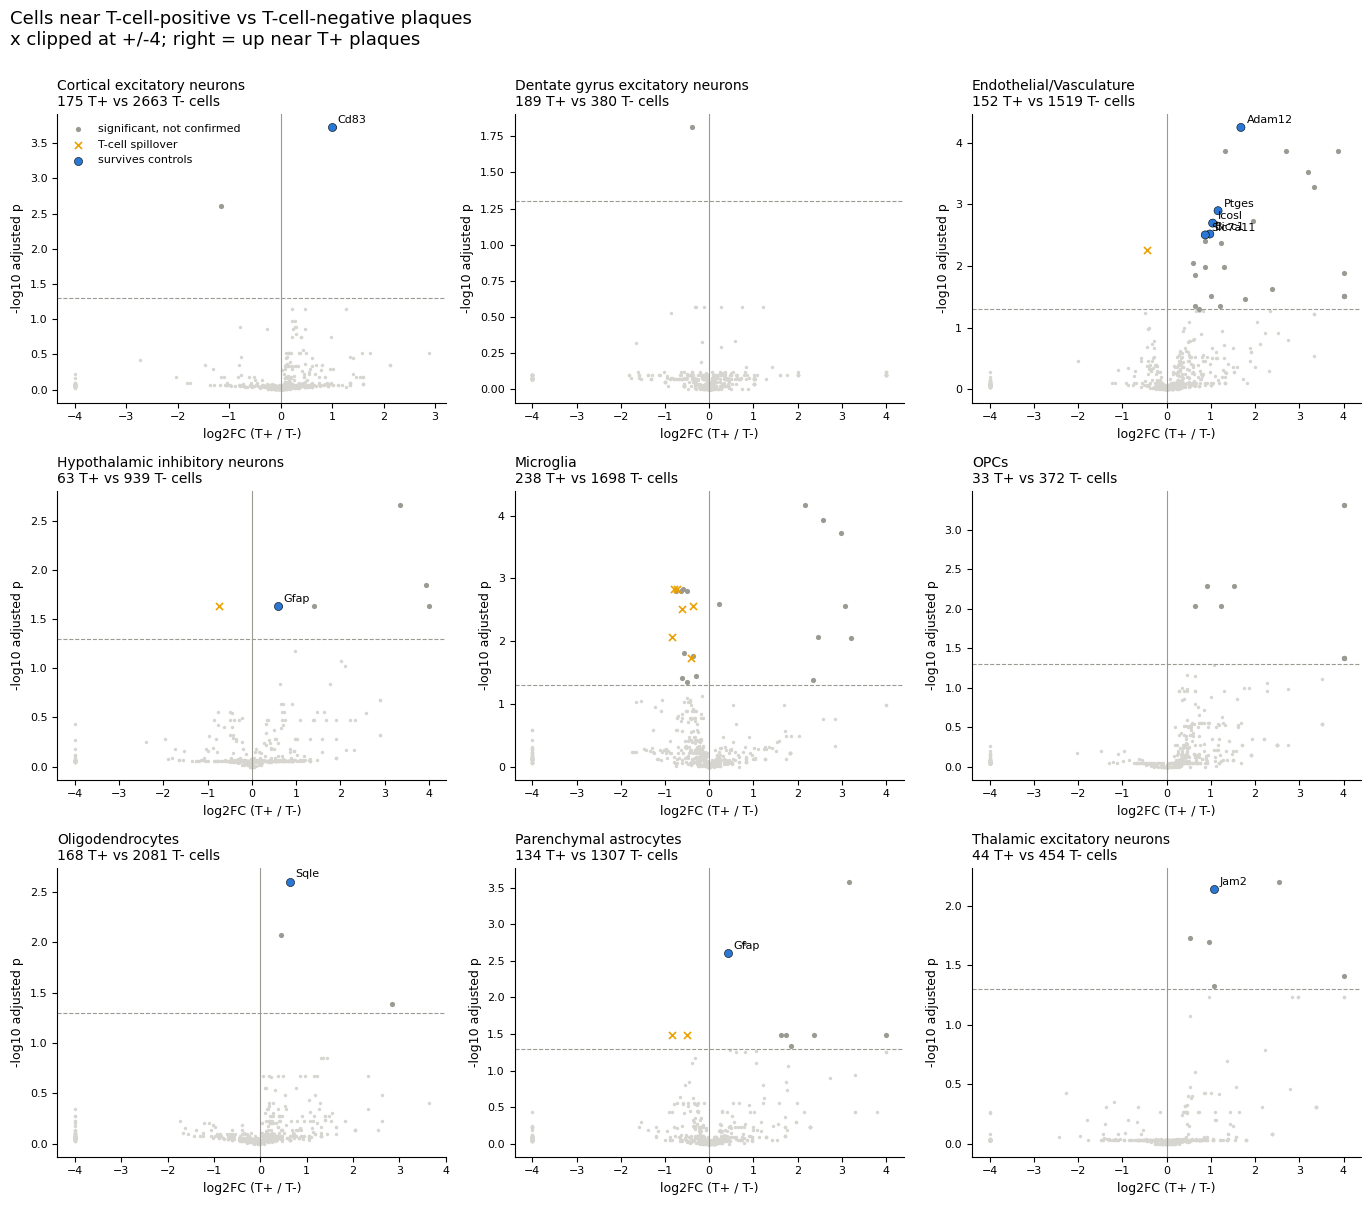

In [9]:
# ---- Volcano per cell type ------------------------------------------------
LFC_LIMIT = 4          # scanpy returns huge LFCs when a group is near-zero
LABEL_TOP = 6

UP_COLOR, DOWN_COLOR = "#2a78d6", "#e34948"
SPILL_COLOR, NS_COLOR = "#eda100", "#d6d5d0"

n = len(deg_by_celltype)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.0 * nrows), squeeze=False)

for index, (label, table) in enumerate(deg_by_celltype.items()):
    ax = axes[index // ncols][index % ncols]
    lfc = table["naive_logfoldchanges"].clip(-LFC_LIMIT, LFC_LIMIT)
    y = -np.log10(table["naive_pvals_adj"].clip(lower=1e-300))

    significant = table["naive_pvals_adj"] < 0.05
    spill = significant & table["tcell_spillover"]
    survives = table["survives_controls"]
    plain = significant & ~spill & ~survives

    ax.scatter(lfc[~significant], y[~significant], s=6, c=NS_COLOR, linewidths=0)
    ax.scatter(lfc[plain], y[plain], s=14, c="#9a9992", linewidths=0,
               label="significant, not confirmed")
    ax.scatter(lfc[spill], y[spill], s=26, marker="x", c=SPILL_COLOR, linewidths=1.2,
               label="T-cell spillover")
    ax.scatter(lfc[survives], y[survives], s=34,
               c=[UP_COLOR if v > 0 else DOWN_COLOR for v in lfc[survives]],
               edgecolors="black", linewidths=0.4, label="survives controls")

    for gene in table.loc[survives].nsmallest(LABEL_TOP, "naive_pvals_adj").index:
        ax.annotate(gene, (lfc[gene], y[gene]), fontsize=8, xytext=(4, 3),
                    textcoords="offset points")

    ax.axhline(-np.log10(0.05), color="#9a9992", linestyle="--", linewidth=0.8)
    ax.axvline(0, color="#9a9992", linewidth=0.8)
    ax.set_title(f"{label}\n{table.n_positive.iloc[0]} T+ vs {table.n_negative.iloc[0]} T- cells",
                 fontsize=10, loc="left")
    ax.set_xlabel("log2FC (T+ / T-)", fontsize=9)
    ax.set_ylabel("-log10 adjusted p", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

for index in range(n, nrows * ncols):
    axes[index // ncols][index % ncols].axis("off")

axes[0][0].legend(fontsize=8, frameon=False, loc="upper left")
fig.suptitle("Cells near T-cell-positive vs T-cell-negative plaques\n"
             f"x clipped at +/-{LFC_LIMIT}; right = up near T+ plaques",
             y=1.0, x=0.01, ha="left", fontsize=13)
plt.tight_layout()
plt.savefig(DEG_DIR / "volcano_by_celltype.png", dpi=250, bbox_inches="tight", facecolor="white")
plt.show()

## 8. Heatmap across cell types

log2FC per gene per cell type. `*` marks padj < 0.05, a box marks a gene that
survives area matching, `†` marks T-cell spillover.

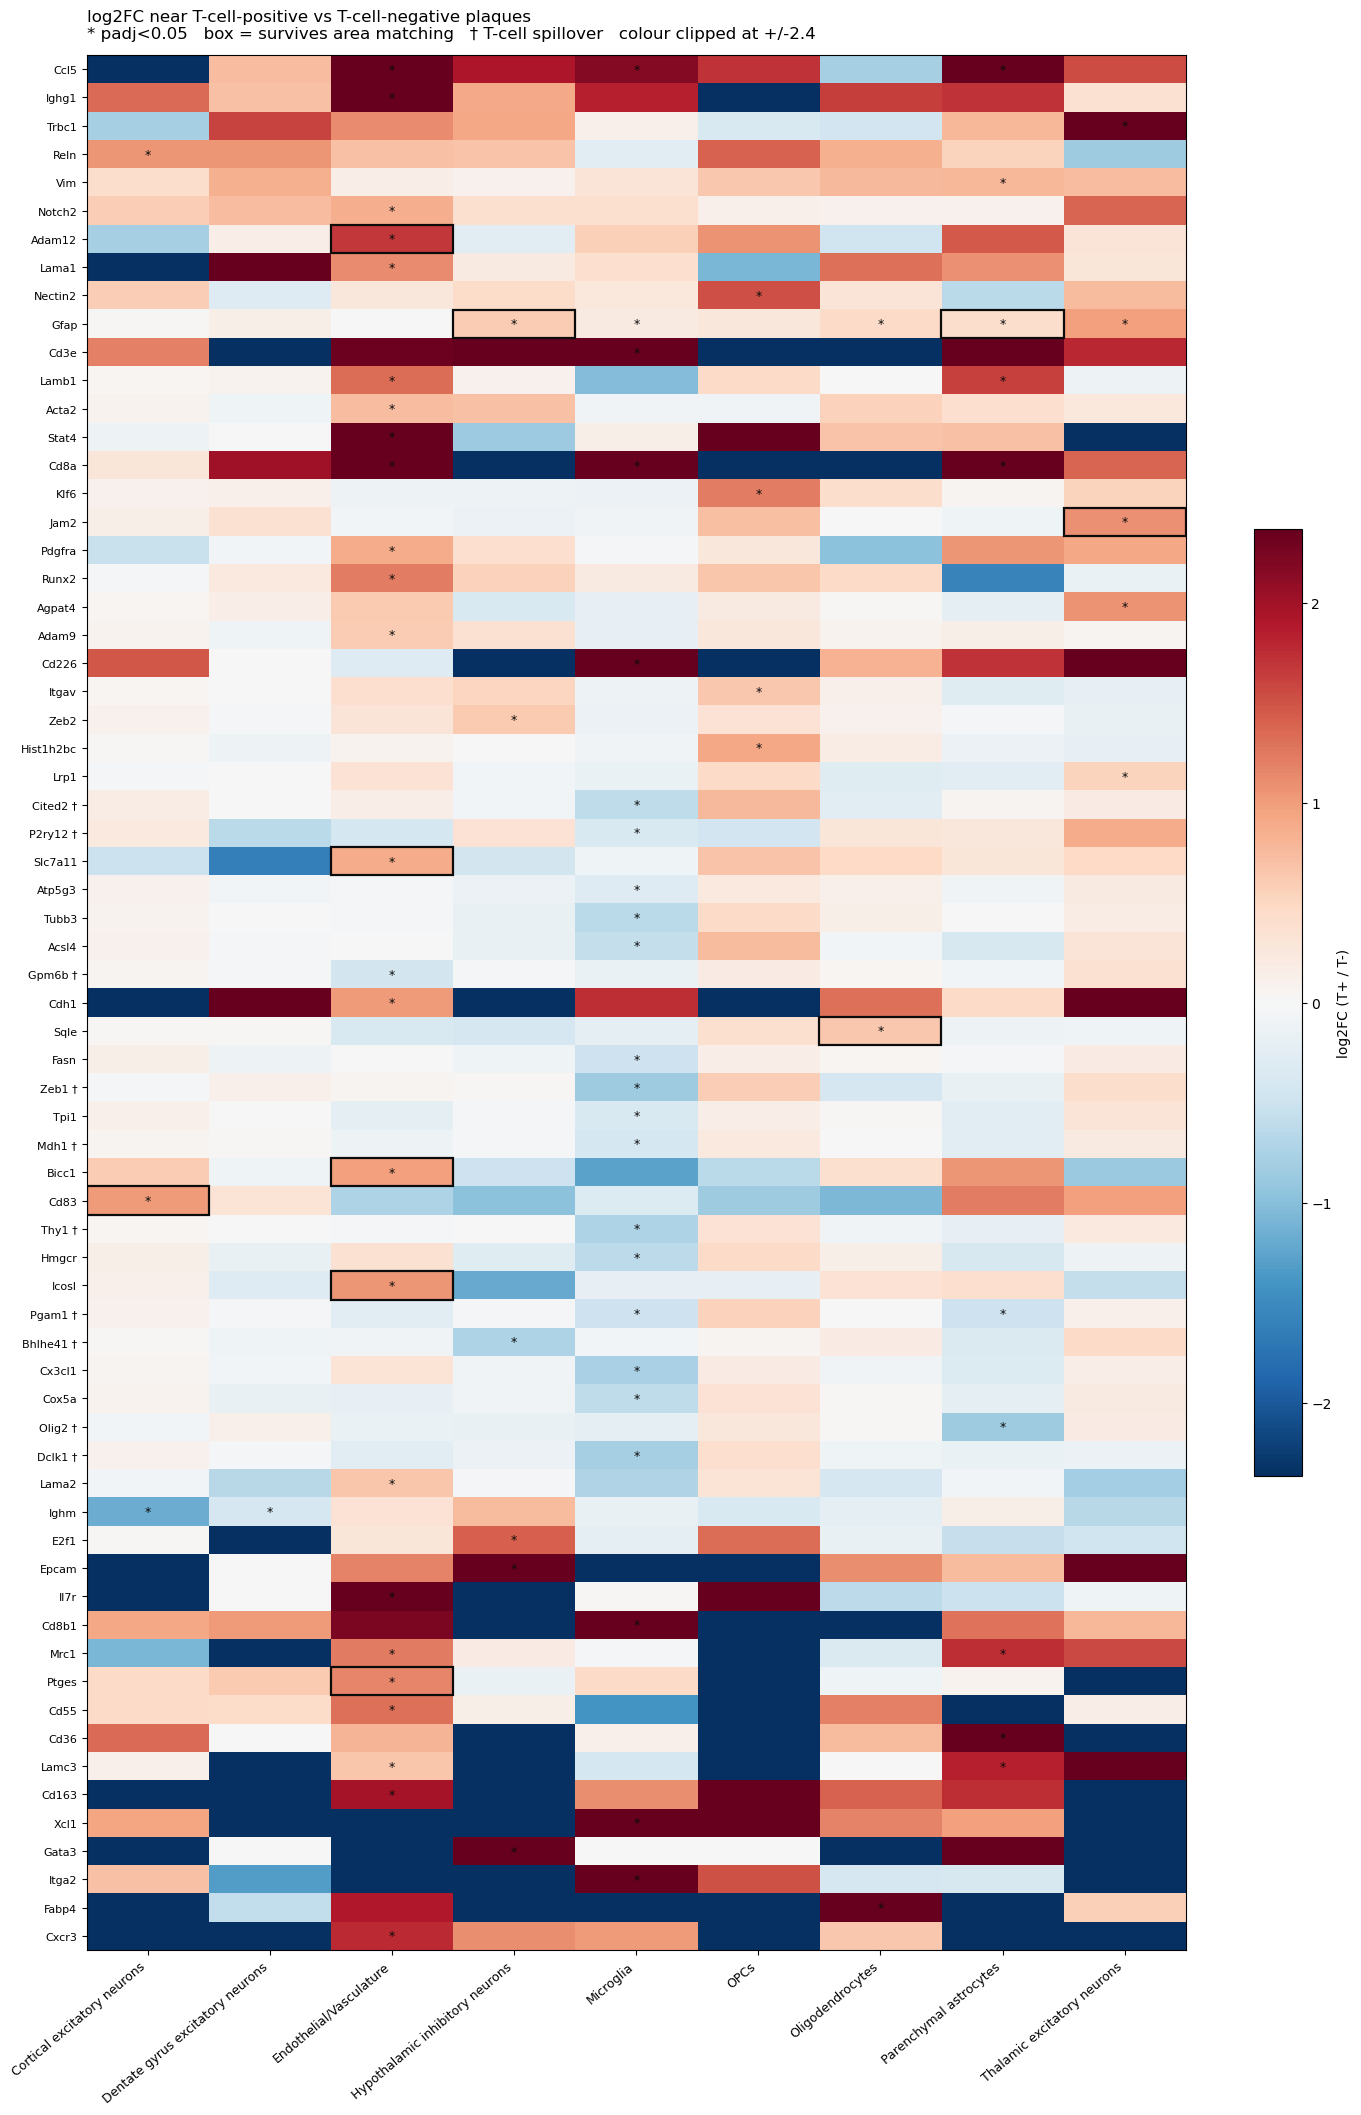

Wrote volcano, heatmap and DEG_all_celltypes.xlsx to /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/11_Microglia_Tcell_Plaques


In [10]:
# ---- Heatmap of the genes that move, across cell types --------------------
# A gene that is near-zero in one group gets an enormous, unreliable fold
# change. Keep only genes whose significant result has an interpretable
# magnitude, or those extremes set the colour scale and hide everything else.
significant_genes = (
    deg_long.loc[(deg_long.naive_pvals_adj < 0.05)
                 & (deg_long.naive_logfoldchanges.abs() < LFC_LIMIT)]
    .sort_values("naive_pvals_adj")["gene"].drop_duplicates().tolist()
)
lfc_matrix = (deg_long.pivot(index="gene", columns="celltype", values="naive_logfoldchanges")
              .loc[significant_genes].clip(-LFC_LIMIT, LFC_LIMIT))
padj_matrix = deg_long.pivot(index="gene", columns="celltype", values="naive_pvals_adj").loc[significant_genes]
survive_matrix = deg_long.pivot(index="gene", columns="celltype", values="survives_controls").loc[significant_genes]
spill_genes = set(deg_long.loc[deg_long.tcell_spillover & (deg_long.naive_pvals_adj < 0.05), "gene"])

# Order: up near T+ first, then down.
lfc_matrix = lfc_matrix.loc[lfc_matrix.mean(axis=1).sort_values(ascending=False).index]
padj_matrix = padj_matrix.loc[lfc_matrix.index]
survive_matrix = survive_matrix.loc[lfc_matrix.index]

fig, ax = plt.subplots(figsize=(1.1 * lfc_matrix.shape[1] + 5, 0.28 * len(lfc_matrix) + 2.5))
# Scale to the bulk of the values, not the extremes: a gene that is near-zero
# in one group produces a huge LFC that would otherwise saturate the whole map.
limit = max(1.0, float(np.nanpercentile(np.abs(lfc_matrix.to_numpy()), 85)))
image = ax.imshow(lfc_matrix, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")

# * marks padj < 0.05 in that cell type; a ring marks genes that survive the controls.
for row in range(lfc_matrix.shape[0]):
    for column in range(lfc_matrix.shape[1]):
        if padj_matrix.iat[row, column] < 0.05:
            ax.text(column, row, "*", ha="center", va="center", fontsize=9, color="#0b0b0b")
        if bool(survive_matrix.iat[row, column]):
            ax.add_patch(plt.Rectangle((column - 0.5, row - 0.5), 1, 1, fill=False,
                                       edgecolor="#0b0b0b", linewidth=1.6))

ax.set_xticks(range(lfc_matrix.shape[1]))
ax.set_xticklabels(lfc_matrix.columns, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(len(lfc_matrix)))
ax.set_yticklabels(
    [f"{g} †" if g in spill_genes else g for g in lfc_matrix.index], fontsize=8
)
ax.set_title("log2FC near T-cell-positive vs T-cell-negative plaques\n"
             f"* padj<0.05   box = survives area matching   † T-cell spillover   colour clipped at +/-{limit:.1f}",
             fontsize=12, loc="left", pad=12)
fig.colorbar(image, ax=ax, shrink=0.5, label="log2FC (T+ / T-)")
plt.tight_layout()
plt.savefig(DEG_DIR / "heatmap_logfc_by_celltype.png", dpi=250, bbox_inches="tight", facecolor="white")
plt.show()

deg_long.to_csv(DEG_DIR / "DEG_all_celltypes.csv", index=False)
with pd.ExcelWriter(DEG_DIR / "DEG_all_celltypes.xlsx", engine="openpyxl") as writer:
    summary.to_excel(writer, sheet_name="summary")
    deg_long.loc[deg_long.naive_pvals_adj < 0.05].round(5).to_excel(
        writer, sheet_name="naive_significant", index=False)
    deg_long.loc[deg_long.survives_controls].round(5).to_excel(
        writer, sheet_name="survives_controls", index=False)
    lfc_matrix.round(3).to_excel(writer, sheet_name="logfc_matrix")
print("Wrote volcano, heatmap and DEG_all_celltypes.xlsx to", DEG_DIR)

## What this shows

**Microglia: nothing.** 17 naive hits, 8 of them T-cell genes (spillover), 0 surviving
area matching. T+ plaques are 1.8x larger (median 175 vs 96 um2), which is the more
parsimonious explanation for any apparent niche difference.

**Endothelium is the one cell type with a signal.** Adam12, Ptges, Bicc1 and Icosl are
all up near T-cell-positive plaques and survive area matching. Icosl is the ICOS
ligand - a T-cell costimulatory molecule - which is the kind of gene you would
predict if vasculature near T-cell-positive plaques is engaged in recruiting or
retaining them. Ptges (prostaglandin E synthase) is the only gene in the whole
analysis that also clears the per-plaque pseudobulk test.

**Elsewhere:** Gfap up in parenchymal astrocytes, Sqle in oligodendrocytes, and
Jam2 / Lrp1 / Agpat4 in thalamic excitatory neurons.

Three caveats. The Gfap call in *hypothalamic inhibitory neurons* is almost certainly
astrocyte spillover - the spillover flag only tests for T-cell genes, so contamination
from other neighbouring cell types is not screened. Only Ptges clears all three tests,
so the rest are candidates rather than results. And the whole T+/T- split rests on 55
T cells across 583 plaques.